# Pembersihan Data & Penandaan Anomali — Penjualan April–September 2020

Notebook ini **khusus** untuk kebersihan data. Notebook `01_analisis_awal_penjualan.ipynb`
menjawab *"berapa omzetnya"*; notebook ini menjawab *"seberapa layak angka itu dipercaya"*.

**Prinsip kerja**

1. **Tandai dulu, buang belakangan.** Setiap baris mentah dipertahankan dan diberi
   *flag*. Penghapusan hanya terjadi di satu tempat (Bagian 6) lewat kebijakan yang
   tertulis eksplisit, sehingga selalu bisa ditelusuri dan dibatalkan.
2. **Anomali ≠ salah.** QTY 400 DUS bisa benar-benar terjadi. Karena itu setiap aturan
   punya *tingkat* (`kritis` / `peringatan` / `info`) dan *saran tindakan* terpisah.
3. **Aturan berbasis konteks, bukan ambang global.** Harga dibandingkan terhadap median
   SKU + satuan yang sama, bukan terhadap seluruh tabel — satu SKU yang dijual per DUS
   dan per PACK memang wajib beda harga.
4. **Robust terhadap pencilan.** Deteksi statistik memakai median dan MAD, bukan
   rata-rata dan simpangan baku, karena rata-rata sendiri sudah tercemar pencilan.

**Alur**

| Bagian | Isi |
|---|---|
| 1 | Muat data mentah + potret integritas awal |
| 2 | Normalisasi struktural (tipe, ejaan, satuan, identitas) |
| 3 | Katalog aturan anomali (registry) |
| 4 | Penerapan aturan → matriks flag & skor anomali |
| 5 | Visualisasi anomali & noise |
| 6 | Kebijakan pembersihan → dataset bersih |
| 7 | Dampak pembersihan (sebelum vs sesudah) |
| 8 | Ekspor berkas & ringkasan temuan |

## 1. Muat data mentah & potret integritas awal

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.width', 170)
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', lambda v: f'{v:,.2f}')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

FILE = 'Data Penjualan April - Sep 2020.xlsx'
DIR_KELUARAN = 'bersih'

# Warna konsisten untuk tingkat keparahan, dipakai di seluruh notebook.
WARNA = {'kritis': '#C44E52', 'peringatan': '#DD8452', 'info': '#4C72B0'}


def baca_xlsx_stdlib(path, sheet='xl/worksheets/sheet1.xml'):
    '''Cadangan bila openpyxl belum terpasang: baca xlsx (zip+xml) ke DataFrame.'''
    import zipfile
    from xml.etree import ElementTree as ET

    ns = '{http://schemas.openxmlformats.org/spreadsheetml/2006/main}'
    z = zipfile.ZipFile(path)
    shared = [''.join(t.text or '' for t in si.iter(ns + 't'))
              for si in ET.fromstring(z.read('xl/sharedStrings.xml'))]

    def kolom(ref):
        huruf = ''.join(c for c in ref if c.isalpha())
        n = 0
        for c in huruf:
            n = n * 26 + (ord(c) - 64)
        return n - 1

    baris = []
    for row in ET.fromstring(z.read(sheet)).find(ns + 'sheetData').findall(ns + 'row'):
        sel = {}
        for c in row.findall(ns + 'c'):
            v = c.find(ns + 'v')
            if v is None or v.text is None:
                continue
            sel[kolom(c.get('r'))] = shared[int(v.text)] if c.get('t') == 's' else float(v.text)
        baris.append(sel)

    lebar = max(max(r) for r in baris if r) + 1
    tabel = [[r.get(i) for i in range(lebar)] for r in baris]
    return pd.DataFrame(tabel[1:], columns=tabel[0])


try:
    mentah = pd.read_excel(FILE, sheet_name='Sheet1')
    print('Dibaca via pd.read_excel (openpyxl).')
except ImportError:
    mentah = baca_xlsx_stdlib(FILE)
    print('openpyxl tidak tersedia -> memakai pembaca cadangan (zip+xml).')

# BARIS_ASLI = nomor baris di Excel (header = baris 1). Kolom ini dipertahankan sampai
# akhir supaya setiap temuan bisa dibuka kembali di berkas sumbernya.
mentah = mentah.reset_index(drop=True)
mentah.insert(0, 'BARIS_ASLI', mentah.index + 2)

print('Dimensi mentah:', mentah.shape)
mentah.head()

openpyxl tidak tersedia -> memakai pembaca cadangan (zip+xml).
Dimensi mentah: (6779, 9)


,BARIS_ASLI,TGL,KODEBARA,NAMABARA,QTY,SATUAN,HARGA,JUMLAH,NAMA
0,2,"43,922.00",JOF-022,JOFRANS NUGGET AYAM REG. 225 GR X 24 PAK,1.00,DUS,"240,000.00","240,000.00",F - (MITRAKU) TOKO SALMAINI HABABAHAN
1,3,"43,922.00",JOF-002,JOFRANS NUGGET AYAM REG. 500 GR X 12 PAK,1.00,DUS,"216,000.00","216,000.00",F - (MITRAKU) TOKO SALMAINI HABABAHAN
2,4,"43,922.00",OKEY-003,OKEY STICK 500 GR X 10 PACK,1.00,DUS,"190,000.00","190,000.00",F - (MITRAKU) TOKO SALMAINI HABABAHAN
3,5,"43,922.00",OKEY-001,OKEY SOSIS 500 GR X 20 PACK,1.00,DUS,"380,000.00","380,000.00",F - (MITRAKU) TOKO SALMAINI HABABAHAN
4,6,"43,922.00",BLF-001,BELFOODS SOSIS AYAM 500 GR X 12 PACK,1.00,DUS,"204,000.00","204,000.00",F - (MITRAKU) TOKO SALMAINI HABABAHAN


In [2]:
# Potret integritas awal: tipe, kekosongan, kardinalitas, dan contoh nilai.
potret = pd.DataFrame({
    'tipe': mentah.dtypes.astype(str),
    'kosong': mentah.isna().sum(),
    'kosong_%': (mentah.isna().mean() * 100).round(2),
    'unik': mentah.nunique(),
    'contoh': [mentah[c].dropna().iloc[0] if mentah[c].notna().any() else None
               for c in mentah.columns],
})
display(potret)

kosong_penuh = int(mentah.drop(columns='BARIS_ASLI').isna().all(axis=1).sum())
print(f'Baris yang seluruh kolomnya kosong : {kosong_penuh}')
print(f'Baris dengan >=1 kolom kosong      : {int(mentah.isna().any(axis=1).sum())}')

,tipe,kosong,kosong_%,unik,contoh
BARIS_ASLI,int64,0,0.00,6779,2
TGL,float64,1,0.01,143,"43,922.00"
KODEBARA,str,1,0.01,268,JOF-022
NAMABARA,str,1,0.01,297,JOFRANS NUGGET AYAM REG. 225 GR X 24 PAK
QTY,float64,1,0.01,76,1.00
SATUAN,str,1,0.01,9,DUS
HARGA,float64,1,0.01,387,"240,000.00"
JUMLAH,float64,1,0.01,1076,"240,000.00"
NAMA,str,1,0.01,229,F - (MITRAKU) TOKO SALMAINI HABABAHAN


Baris yang seluruh kolomnya kosong : 1
Baris dengan >=1 kolom kosong      : 1


Kekosongan di tabel ini seragam di semua kolom — cirinya bukan "data hilang sebagian",
melainkan **baris pemisah kosong** yang ikut terbaca dari Excel. Baris seperti itu
ditangani di Bagian 2, bukan dengan imputasi.

## 2. Normalisasi struktural

Normalisasi dilakukan **sebelum** deteksi anomali. Alasannya: sebagian besar "anomali"
yang muncul di data mentah sebenarnya hanya perbedaan ejaan. Kalau `PAC` dan `PACK`
tidak diseragamkan lebih dulu, aturan konsistensi harga akan melaporkan puluhan temuan
palsu, dan temuan yang benar-benar penting tenggelam di antaranya.

Yang diseragamkan:

| Objek | Masalah di data mentah | Perlakuan |
|---|---|---|
| `TGL` | tersimpan sebagai *serial* Excel | konversi dengan origin `1899-12-30` |
| `KODEBARA` | `MANTUL - 001` vs `MANTUL-001` | rapatkan spasi di sekitar tanda hubung |
| `SATUAN` | `PAC`/`PACK`, `BAL`/`BALL` | peta ke bentuk kanonik |
| `NAMABARA` | beberapa kode punya >1 ejaan nama | ambil ejaan paling sering per kode |
| `NAMA` | `C - ADEK FROZEN` vs `ADEK FROZEN` | pecah jadi `KANAL` / `GRUP` / `PELANGGAN` |

Setiap normalisasi mencatat berapa baris yang tersentuh, sehingga tidak ada perubahan
yang terjadi diam-diam.

In [3]:
jejak = []          # catatan setiap langkah normalisasi


def catat(langkah, terdampak, keterangan):
    jejak.append({'langkah': langkah, 'baris_terdampak': int(terdampak),
                  'keterangan': keterangan})


d = mentah.copy()
d.columns = [c.strip().upper() for c in d.columns]

# --- Baris kosong penuh: disingkirkan di sini karena bukan observasi sama sekali.
#     Nomor barisnya tetap tercatat di jejak agar bisa diverifikasi ke Excel.
kolom_data = [c for c in d.columns if c != 'BARIS_ASLI']
kosong = d[kolom_data].isna().all(axis=1)
baris_kosong_asli = d.loc[kosong, 'BARIS_ASLI'].tolist()
d = d[~kosong].copy()
catat('buang baris kosong penuh', kosong.sum(), f'baris Excel: {baris_kosong_asli}')

# --- Tanggal ---
if not pd.api.types.is_datetime64_any_dtype(d['TGL']):
    d['TGL'] = pd.to_datetime(d['TGL'].astype(float), unit='D', origin='1899-12-30')
d['BULAN'] = d['TGL'].dt.to_period('M').dt.to_timestamp()
d['HARI'] = d['TGL'].dt.day_name()

# --- Numerik ---
for c in ['QTY', 'HARGA', 'JUMLAH']:
    d[c] = pd.to_numeric(d[c], errors='coerce')

# --- Teks: rapikan spasi ganda dan spasi tepi ---
for c in ['KODEBARA', 'NAMABARA', 'SATUAN', 'NAMA']:
    semula = d[c].astype('string')
    d[c] = semula.str.replace(r'\s+', ' ', regex=True).str.strip()
    catat(f'rapikan spasi {c}', (semula != d[c]).sum(), 'spasi ganda / spasi tepi')

# --- Kode barang kanonik: 'MANTUL - 001' dan 'MANTUL-001' adalah SKU yang sama ---
d['KODE'] = d['KODEBARA'].str.upper().str.replace(r'\s*-\s*', '-', regex=True)
catat('kanonikkan KODEBARA', (d['KODE'] != d['KODEBARA'].str.upper()).sum(),
      'spasi di sekitar tanda hubung dirapatkan')

# --- Satuan kanonik ---
PETA_SATUAN = {'PAC': 'PACK', 'PCK': 'PACK', 'BALL': 'BAL', 'DOS': 'DUS'}
d['SATUAN_K'] = d['SATUAN'].str.upper().replace(PETA_SATUAN)
catat('kanonikkan SATUAN', (d['SATUAN_K'] != d['SATUAN'].str.upper()).sum(),
      f'peta: {PETA_SATUAN}')

# --- Nama barang kanonik: satu kode -> satu ejaan (modus) ---
kanonik_nama = (d.dropna(subset=['KODE'])
                  .groupby('KODE')['NAMABARA']
                  .agg(lambda s: s.value_counts().idxmax()))
d['NAMA_BARANG'] = d['KODE'].map(kanonik_nama).fillna(d['NAMABARA'])
n_kode_multinama = int((d.groupby('KODE')['NAMABARA'].nunique() > 1).sum())
catat('kanonikkan NAMABARA', (d['NAMA_BARANG'] != d['NAMABARA']).sum(),
      f'{n_kode_multinama} kode punya >1 ejaan nama')

d['BRAND'] = d['NAMA_BARANG'].str.split().str[0].str.upper()

# --- Identitas pelanggan: "F - (MITRAKU) TOKO SALMAINI" -> kanal / grup / pelanggan ---
POLA_NAMA = r'^\s*(?:(?P<KANAL>[A-Z0-9]{1,3})\s*-\s*)?(?:\((?P<GRUP>[^)]*)\)\s*)?(?P<PELANGGAN>.*)$'
pecah = d['NAMA'].str.extract(POLA_NAMA)
d['KANAL'] = pecah['KANAL'].fillna('(tanpa kode)')
d['GRUP'] = pecah['GRUP'].fillna('(tanpa grup)')
d['PELANGGAN'] = (pecah['PELANGGAN'].str.strip()
                                    .replace('', pd.NA)
                                    .fillna(d['NAMA'])
                                    .str.upper())
catat('pecah NAMA -> KANAL/GRUP/PELANGGAN',
      (d['PELANGGAN'] != d['NAMA'].str.upper()).sum(),
      'prefiks kanal & grup dipisahkan dari nama outlet')

# --- Kanal kanonik per pelanggan: satu outlet seharusnya satu kanal (ambil modus) ---
kanal_modus = (d[d['KANAL'] != '(tanpa kode)']
               .groupby('PELANGGAN')['KANAL']
               .agg(lambda s: s.value_counts().idxmax()))
d['KANAL_K'] = d['PELANGGAN'].map(kanal_modus).fillna(d['KANAL'])

# --- Turunan untuk pemeriksaan aritmetika ---
d['JUMLAH_HITUNG'] = d['QTY'] * d['HARGA']
d['SELISIH'] = (d['JUMLAH'] - d['JUMLAH_HITUNG']).round(2)
# RASIO < 1 berarti nilai baris lebih kecil dari QTY x HARGA -> indikasi diskon.
d['RASIO'] = np.where(d['JUMLAH_HITUNG'] > 0, d['JUMLAH'] / d['JUMLAH_HITUNG'], np.nan)
# JUMLAH dianggap otoritatif (sudah memuat diskon), jadi harga efektif dihitung darinya.
d['HARGA_EFEKTIF'] = np.where(d['QTY'] > 0, d['JUMLAH'] / d['QTY'], np.nan)

d = d.reset_index(drop=True)
display(pd.DataFrame(jejak))
print('Dimensi setelah normalisasi:', d.shape)

,langkah,baris_terdampak,keterangan
0,buang baris kosong penuh,1,baris Excel: [6780]
1,rapikan spasi KODEBARA,0,spasi ganda / spasi tepi
2,rapikan spasi NAMABARA,20,spasi ganda / spasi tepi
3,rapikan spasi SATUAN,0,spasi ganda / spasi tepi
4,rapikan spasi NAMA,0,spasi ganda / spasi tepi
5,kanonikkan KODEBARA,203,spasi di sekitar tanda hubung dirapatkan
6,kanonikkan SATUAN,23,"peta: {'PAC': 'PACK', 'PCK': 'PACK', 'BALL': '..."
7,kanonikkan NAMABARA,176,25 kode punya >1 ejaan nama
8,pecah NAMA -> KANAL/GRUP/PELANGGAN,3703,prefiks kanal & grup dipisahkan dari nama outlet


Dimensi setelah normalisasi: (6778, 23)


In [4]:
# Bukti bahwa normalisasi identitas memang menyatukan entitas, bukan sekadar mengubah teks.
varian_nama = d.groupby('PELANGGAN')['NAMA'].nunique().sort_values(ascending=False)
n_varian = int((varian_nama > 1).sum())
print(f'Pelanggan yang di data mentah tertulis dalam >1 bentuk: {n_varian} '
      f'(dari {d["PELANGGAN"].nunique()} pelanggan setelah penyatuan)')
print(f'NAMA unik mentah: {d["NAMA"].nunique()}  ->  PELANGGAN unik: {d["PELANGGAN"].nunique()}')

contoh = (d[d['PELANGGAN'].isin(varian_nama[varian_nama > 1].index)]
          .groupby(['PELANGGAN', 'NAMA']).size().rename('baris'))
display(contoh.head(16).to_frame())

Pelanggan yang di data mentah tertulis dalam >1 bentuk: 46 (dari 183 pelanggan setelah penyatuan)
NAMA unik mentah: 229  ->  PELANGGAN unik: 183


baris
PELANGGAN          NAMA                         
ADEK FROZEN        ADEK FROZEN               202
                   C - ADEK FROZEN            84
ANJANI FROZEN FOOD ANJANI FROZEN FOOD         87
                   C - ANJANI FROZEN FOOD     54
ANTON              ANTON                     106
                   C - ANTON                  39
ARIS FOOD          ARIS FOOD                  17
                   C - ARIS FOOD               3
BRAGA FROZEN FOOD  BRAGA FROZEN FOOD           6
                   C - BRAGA FROZEN FOOD      18
EGI / PUTRI        C - EGI / PUTRI             6
                   EGI / PUTRI                10
FADIL ANAK BOS     C - FADIL ANAK BOS         57
                   FADIL ANAK BOS             75
FIRDON             C - FIRDON                 15
                   FIRDON                     10

Angka di atas adalah alasan utama notebook ini ada: tanpa penyatuan identitas, satu
outlet seperti `ADEK FROZEN` terhitung sebagai dua pelanggan berbeda (`ADEK FROZEN` dan
`C - ADEK FROZEN`), sehingga jumlah pelanggan melar dan peringkat pelanggan teratas
salah urut.

## 3. Katalog aturan anomali

Setiap aturan didaftarkan lewat satu fungsi `daftar()` dengan bentuk yang sama:
kode, kategori, tingkat, penjelasan, *mask* boolean, dan saran tindakan. Formatnya
seragam supaya Bagian 4–6 bisa memperlakukan semua aturan secara generik — menambah
aturan baru cukup satu pemanggilan, tanpa menyentuh kode di bawahnya.

**Tingkat keparahan**

- `kritis` — merusak agregat bila dibiarkan (ganda, baris tak valid, non-penjualan).
- `peringatan` — mencurigakan, perlu konfirmasi manusia sebelum diputuskan.
- `info` — menyimpang secara statistik tetapi sangat mungkin sah (pesanan besar, diskon).

### 3.1 Alat bantu statistik robust

In [5]:
def z_robust(nilai, grup, n_min=5):
    '''Skor-z robust (median + MAD) di dalam tiap grup.

    Rata-rata dan simpangan baku tidak dipakai karena keduanya ikut tertarik oleh
    pencilan yang justru sedang dicari. MAD dikalikan 1.4826 agar skalanya setara
    simpangan baku pada sebaran normal.

    Grup dengan anggota < n_min atau MAD = 0 dikembalikan sebagai NaN: datanya belum
    cukup untuk menyimpulkan apa pun, dan NaN tidak akan pernah lolos perbandingan
    ambang sehingga aman dipakai langsung sebagai mask.
    '''
    med = nilai.groupby(grup).transform('median')
    mad = (nilai - med).abs().groupby(grup).transform('median') * 1.4826
    n = nilai.groupby(grup).transform('size')
    skala = mad.where(mad > 0)
    return ((nilai - med) / skala).where(n >= n_min)


def pagar_iqr(nilai, k=3.0):
    '''Batas atas/bawah gaya Tukey. Dipakai pada skala log untuk nilai rupiah, karena
    sebaran nilai transaksi condong ke kanan (banyak kecil, sedikit sangat besar).'''
    q1, q3 = nilai.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr


ATURAN = []


def daftar(kode, kategori, tingkat, deskripsi, mask, saran):
    '''Daftarkan satu aturan anomali ke katalog.'''
    mask = pd.Series(mask, index=d.index).fillna(False).astype(bool)
    ATURAN.append({'kode': kode, 'kategori': kategori, 'tingkat': tingkat,
                   'deskripsi': deskripsi, 'saran': saran, 'mask': mask})
    return mask


print('Katalog siap. Aturan terdaftar:', len(ATURAN))

Katalog siap. Aturan terdaftar: 0


### 3.2 Kelengkapan & validitas nilai

Aturan paling dasar: apakah baris ini benar-benar sebuah transaksi penjualan?

In [6]:
daftar('K01', 'kelengkapan', 'kritis',
       'Kolom kunci kosong (TGL / KODE / QTY / JUMLAH)',
       d[['TGL', 'KODE', 'QTY', 'JUMLAH']].isna().any(axis=1),
       'Baris tidak dapat dianalisis — keluarkan dari dataset analisis.')

daftar('K02', 'validitas', 'kritis',
       'QTY <= 0',
       d['QTY'] <= 0,
       'Cek apakah retur (harus bernilai negatif konsisten) atau salah input.')

daftar('K03', 'validitas', 'kritis',
       'HARGA = 0 sehingga JUMLAH = 0',
       (d['HARGA'] <= 0) & (d['JUMLAH'] <= 0),
       'Barang keluar tanpa nilai jual: sampling/bonus. Keluarkan dari omzet, '
       'pertahankan bila menganalisis kuantitas keluar.')

daftar('K04', 'validitas', 'peringatan',
       'JUMLAH <= 0 padahal HARGA > 0',
       (d['JUMLAH'] <= 0) & (d['HARGA'] > 0),
       'Kombinasi yang tidak konsisten — konfirmasi ke sumber.')

# "Non-penjualan" dikenali dari dua sisi: nilainya nol, atau nama pihaknya menyatakan
# demikian. Keduanya digabung agar tidak ada bonus yang lolos hanya karena harganya
# terlanjur diisi.
KATA_NON_JUAL = r'SAMPLING|SAMPEL|BONUS|GRATIS|RUSAK|RETUR'
daftar('K05', 'noise', 'kritis',
       'Baris non-penjualan (sampling/bonus/retur) menurut nama pihak atau nilai nol',
       d['NAMA'].str.contains(KATA_NON_JUAL, case=False, na=False) | (d['JUMLAH'] <= 0),
       'Bukan omzet. Pisahkan agar tidak mengencerkan rata-rata nilai transaksi.')

print(f'{len(ATURAN)} aturan terdaftar sampai tahap ini.')

5 aturan terdaftar sampai tahap ini.


### 3.3 Duplikasi

Dua tingkat: **duplikat persis** (seluruh kolom identitas sama) dan **duplikat lunak**
(tanggal, pelanggan, SKU, QTY, dan harga sama, tetapi baris terpisah).

Perlu kehati-hatian di sini. Outlet `CASH` wajar membeli barang yang sama dua kali dalam
satu hari lewat dua struk berbeda, jadi duplikat lunak **bukan** bukti kesalahan — ia
hanya kandidat. Karena itu tingkatnya `peringatan`, bukan `kritis`, dan baris pertama
tiap kelompok tidak pernah ikut ditandai.

In [7]:
KOLOM_IDENTITAS = ['TGL', 'KODE', 'QTY', 'SATUAN_K', 'HARGA', 'JUMLAH', 'NAMA']

daftar('D01', 'duplikasi', 'kritis',
       'Duplikat persis (kemunculan ke-2 dan seterusnya)',
       d.duplicated(subset=KOLOM_IDENTITAS, keep='first'),
       'Hapus salinan berlebih; pertahankan kemunculan pertama.')

# Dibuat eksklusif terhadap D01 agar aturannya benar-benar berarti "mirip tetapi
# bukan salinan persis". Kalau hasilnya 0, itu kesimpulan yang berguna: tidak ada
# kandidat ganda yang lolos hanya karena ejaan nama pelanggannya berbeda.
lunak = d.duplicated(subset=['TGL', 'PELANGGAN', 'KODE', 'QTY', 'HARGA'], keep='first')
daftar('D02', 'duplikasi', 'peringatan',
       'Duplikat lunak: identik pada tanggal+pelanggan+SKU+QTY+harga, tetapi bukan D01',
       lunak & ~d.duplicated(subset=KOLOM_IDENTITAS, keep='first'),
       'Bisa jadi dua struk sah di hari yang sama — konfirmasi sebelum dihapus.')

n_terlibat = int(d.duplicated(subset=KOLOM_IDENTITAS, keep=False).sum())
print(f'Baris yang terlibat duplikat persis : {n_terlibat} '
      f'({int(d.duplicated(subset=KOLOM_IDENTITAS).sum())} salinan berlebih)')

display(d[d.duplicated(subset=KOLOM_IDENTITAS, keep=False)]
        .sort_values(KOLOM_IDENTITAS)
        [['BARIS_ASLI', 'TGL', 'KODE', 'NAMA_BARANG', 'QTY', 'HARGA', 'JUMLAH',
          'PELANGGAN']].head(10))

Baris yang terlibat duplikat persis : 143 (73 salinan berlebih)


,BARIS_ASLI,TGL,KODE,NAMA_BARANG,QTY,HARGA,JUMLAH,PELANGGAN
219,221,2020-04-06,CHA-006,CHAMP BASO 500 GR X 10 PACK,1.00,"220,000.00","220,000.00",TOKO DENIS
223,225,2020-04-06,CHA-006,CHAMP BASO 500 GR X 10 PACK,1.00,"220,000.00","220,000.00",TOKO DENIS
504,506,2020-04-16,MI-003,MIAMI 8 LTR NEAPOLITAN,1.00,"125,000.00","125,000.00",CASH
528,530,2020-04-16,MI-003,MIAMI 8 LTR NEAPOLITAN,1.00,"125,000.00","125,000.00",CASH
641,643,2020-04-18,CONE-005,CONE TP 17 ISI 20 ( SEDANG ),2.00,"5,000.00","10,000.00",CASH
643,645,2020-04-18,CONE-005,CONE TP 17 ISI 20 ( SEDANG ),2.00,"5,000.00","10,000.00",CASH
655,657,2020-04-20,MI-003,MIAMI 8 LTR NEAPOLITAN,1.00,"125,000.00","125,000.00",CASH
656,658,2020-04-20,MI-003,MIAMI 8 LTR NEAPOLITAN,1.00,"125,000.00","125,000.00",CASH
687,689,2020-04-20,MI-003,MIAMI 8 LTR NEAPOLITAN,1.00,"125,000.00","125,000.00",CASH
751,753,2020-04-23,LUTOSA-003,LUTOSA SHOESTRING 500 GR X 20 PACK,1.00,"280,000.00","280,000.00",KIKI TORA


### 3.4 Konsistensi aritmetika: `JUMLAH` vs `QTY × HARGA`

Ini pemeriksaan paling informatif di dataset ini. Sekilas, puluhan baris dengan
`JUMLAH ≠ QTY × HARGA` tampak seperti puluhan kesalahan hitung. Sebaran rasionya
menunjukkan hal lain: nilainya menumpuk di angka bulat seperti 0.90, 0.92, dan 0.95 —
pola potongan harga, bukan kesalahan aritmetika acak.

Karena itu aturan dipisah tiga:

- rasio dalam rentang diskon wajar (0.80–0.999) → `info`, dicatat sebagai **diskon**;
- rasio jauh di bawah itu → `peringatan`, potongan terlalu dalam tanpa penjelasan;
- rasio di atas 1 → `peringatan`, `JUMLAH` melebihi `QTY × HARGA` dan tidak punya
  padanan bisnis yang wajar.

In [8]:
BATAS_DISKON = 0.80          # potongan lebih dalam dari 20% dianggap perlu konfirmasi
TOLERANSI = 0.5              # rupiah; di bawah ini dianggap pembulatan biasa

tak_cocok = (d['SELISIH'].abs() > TOLERANSI) & d['JUMLAH_HITUNG'].gt(0)

daftar('A01', 'aritmetika', 'info',
       f'Diskon wajar: JUMLAH = {BATAS_DISKON:.0%}-100% dari QTY x HARGA',
       tak_cocok & d['RASIO'].between(BATAS_DISKON, 0.999),
       'Sah. Pakai JUMLAH (bukan QTY x HARGA) sebagai nilai omzet.')

daftar('A02', 'aritmetika', 'peringatan',
       f'Potongan tidak wajar: JUMLAH < {BATAS_DISKON:.0%} dari QTY x HARGA',
       tak_cocok & d['RASIO'].lt(BATAS_DISKON),
       'Potongan sangat dalam — cek promo khusus atau salah ketik nominal.')

daftar('A03', 'aritmetika', 'peringatan',
       'JUMLAH melebihi QTY x HARGA',
       tak_cocok & d['RASIO'].gt(1.001),
       'Tidak ada penjelasan bisnis yang wajar — kemungkinan salah input.')

print(f'Baris dengan JUMLAH != QTY x HARGA : {int(tak_cocok.sum())}')
print('\nSebaran rasio JUMLAH / (QTY x HARGA) pada baris tersebut:')
display(d.loc[tak_cocok, 'RASIO'].round(3).value_counts()
        .sort_index().rename('baris').to_frame())

print('Baris dengan potongan terdalam:')
display(d[tak_cocok & d['RASIO'].lt(BATAS_DISKON)]
        .sort_values('RASIO')
        [['BARIS_ASLI', 'TGL', 'KODE', 'NAMA_BARANG', 'QTY', 'HARGA',
          'JUMLAH', 'RASIO', 'PELANGGAN']].head(10))

Baris dengan JUMLAH != QTY x HARGA : 77

Sebaran rasio JUMLAH / (QTY x HARGA) pada baris tersebut:


,baris
RASIO,
0.50,4
0.85,4
0.90,11
0.92,1
0.92,20
0.95,14
0.96,4
0.97,19


Baris dengan potongan terdalam:


,BARIS_ASLI,TGL,KODE,NAMA_BARANG,QTY,HARGA,JUMLAH,RASIO,PELANGGAN
2323,2325,2020-06-09,MIT-005,MITRAKU CHILI&CELERY FISHCAKE 500GR X 20,10.00,"28,900.00","144,500.00",0.50,PAK ERWIN
2332,2334,2020-06-09,MIT-005,MITRAKU CHILI&CELERY FISHCAKE 500GR X 20,6.00,"28,900.00","86,700.00",0.50,PAK ERWIN
4557,4559,2020-08-03,MIT-005,MITRAKU CHILI&CELERY FISHCAKE 500GR X 20,27.00,"28,900.00","390,150.00",0.50,PAK ERWIN
4558,4560,2020-08-03,MIT-013,MITRAKU SCALLOP 200 GR X 40 PACK,51.00,"9,900.00","252,450.00",0.50,PAK ERWIN


### 3.5 Integritas referensial

Master data yang rapi punya pemetaan satu-ke-satu antara kode dan nama barang.
Pelanggaran di sini tidak membuat total omzet salah, tetapi membuat **pengelompokan**
salah — satu SKU pecah menjadi beberapa baris di peringkat produk.

In [9]:
# Satu kode -> banyak ejaan nama (sudah dinormalkan di Bagian 2, tetapi tetap dicatat
# supaya masalah master data-nya terlihat dan bisa diperbaiki di sistem sumber).
kode_multinama = d.groupby('KODE')['NAMABARA'].nunique()
kode_multinama = kode_multinama[kode_multinama > 1].index

daftar('R01', 'referensial', 'info',
       'Kode barang punya >1 ejaan nama (sudah diseragamkan)',
       d['KODE'].isin(kode_multinama),
       'Perbaiki master barang di sistem sumber agar ejaannya tunggal.')

# Kebalikannya, dan lebih berbahaya: dua kode berbeda untuk barang yang sama akan
# memecah penjualan SKU itu menjadi dua baris terpisah di semua peringkat produk.
nama_multikode = d.groupby('NAMABARA')['KODE'].nunique()
nama_multikode = nama_multikode[nama_multikode > 1].index

daftar('R02', 'referensial', 'peringatan',
       'Nama barang sama dipakai oleh >1 kode barang',
       d['NAMABARA'].isin(nama_multikode),
       'Kemungkinan kode ganda untuk barang identik — perlu penggabungan SKU.')

# Satu pelanggan tercatat di lebih dari satu kanal.
kanal_ganda = d[d['KANAL'] != '(tanpa kode)'].groupby('PELANGGAN')['KANAL'].nunique()
kanal_ganda = kanal_ganda[kanal_ganda > 1].index

daftar('R03', 'referensial', 'peringatan',
       'Pelanggan tercatat pada >1 kode kanal',
       d['PELANGGAN'].isin(kanal_ganda),
       'Tentukan kanal yang benar; analisis per kanal belum dapat dipercaya sebelum itu.')

print(f'Kode dengan >1 ejaan nama      : {len(kode_multinama)}')
print(f'Nama dipakai >1 kode           : {len(nama_multikode)}')
print(f'Pelanggan dengan kanal ganda   : {len(kanal_ganda)}')

if len(nama_multikode):
    print('\nNama barang yang dipakai lebih dari satu kode:')
    display(d[d['NAMABARA'].isin(nama_multikode)]
            .groupby(['NAMABARA', 'KODE']).size().rename('baris').to_frame())
if len(kanal_ganda):
    print('Pelanggan dengan kanal ganda:')
    display(d[d['PELANGGAN'].isin(kanal_ganda)]
            .groupby(['PELANGGAN', 'KANAL']).size().rename('baris').to_frame().head(12))

Kode dengan >1 ejaan nama      : 25
Nama dipakai >1 kode           : 1
Pelanggan dengan kanal ganda   : 12

Nama barang yang dipakai lebih dari satu kode:


baris
NAMABARA                          KODE             
LUTOSA SHOESTRING 2.5 KG X 4 PACK ARTHUR-001      5
                                  LUTOSA-002    167

Pelanggan dengan kanal ganda:


baris
PELANGGAN             KANAL       
HARUM MANIS           E         26
                      F         23
KOPERASI KUSUMA BAKTI B         12
                      F         19
MAKMUR JAYA           E          7
                      F          1
MANDIRI MART          B          8
                      F          9
MITRA MART            AL        12
                      I         10
PAK ERWIN             C         71
                      E         58

### 3.6 Pencilan statistik

Tiga sudut pandang berbeda, masing-masing menjawab pertanyaan yang berbeda:

| Aturan | Pertanyaan | Pembanding |
|---|---|---|
| `S01` / `S02` | Apakah harganya wajar? | median harga SKU + satuan yang sama |
| `S03` | Apakah kuantitasnya wajar? | median QTY untuk SKU yang sama |
| `S04` | Apakah nilai barisnya wajar? | sebaran seluruh transaksi (skala log) |

Harga **wajib** dibandingkan per `KODE + SATUAN`. Membandingkan harga DUS terhadap harga
PACK untuk SKU yang sama akan menghasilkan "pencilan" di hampir setiap baris, padahal
selisihnya memang seharusnya ada.

In [10]:
harga_positif = d['HARGA'].where(d['HARGA'] > 0)
d['Z_HARGA'] = z_robust(harga_positif, [d['KODE'], d['SATUAN_K']], n_min=5)
d['MEDIAN_HARGA'] = harga_positif.groupby([d['KODE'], d['SATUAN_K']]).transform('median')
# Baris berharga 0 sengaja dibiarkan NaN: itu urusan aturan K03/K05, bukan
# penyimpangan harga. Tanpa ini, 58 baris sampling ikut terjaring S01.
d['DEV_HARGA'] = harga_positif / d['MEDIAN_HARGA'] - 1

daftar('S01', 'pencilan', 'peringatan',
       'Harga menyimpang >30% dari median SKU+satuan yang sama',
       d['DEV_HARGA'].abs() > 0.30,
       'Kandidat salah ketik harga atau harga khusus — cek nota aslinya.')

daftar('S02', 'pencilan', 'info',
       'Harga menyimpang secara statistik (|z robust| > 5)',
       d['Z_HARGA'].abs() > 5,
       'Menyimpang dari kebiasaan SKU ini, tetapi bisa jadi tier harga pelanggan.')

d['Z_QTY'] = z_robust(d['QTY'], d['KODE'], n_min=8)
daftar('S03', 'pencilan', 'info',
       'Kuantitas jauh di atas kebiasaan SKU (z robust > 8)',
       d['Z_QTY'] > 8,
       'Umumnya pesanan borongan yang sah — jangan dihapus, cukup dicatat.')

log_jumlah = np.log10(d['JUMLAH'].where(d['JUMLAH'] > 0))
bawah, atas = pagar_iqr(log_jumlah.dropna(), k=3.0)
daftar('S04', 'pencilan', 'info',
       'Nilai baris ekstrem terhadap seluruh transaksi (pagar IQR pada skala log)',
       (log_jumlah > atas) | (log_jumlah < bawah),
       'Transaksi bernilai tidak biasa — verifikasi yang bernilai sangat besar.')

print(f'Pagar nilai baris: Rp {10 ** bawah:,.0f}  s/d  Rp {10 ** atas:,.0f}')
print('\nHarga paling menyimpang dari median SKU+satuan:')
display(d[d['DEV_HARGA'].abs() > 0.30]
        .assign(dev_persen=lambda x: (x['DEV_HARGA'] * 100).round(1))
        .sort_values('dev_persen', key=abs, ascending=False)
        [['BARIS_ASLI', 'TGL', 'KODE', 'NAMA_BARANG', 'SATUAN_K', 'HARGA',
          'MEDIAN_HARGA', 'dev_persen', 'PELANGGAN']].head(12))

Pagar nilai baris: Rp 1,213  s/d  Rp 54,907,061

Harga paling menyimpang dari median SKU+satuan:


,BARIS_ASLI,TGL,KODE,NAMA_BARANG,SATUAN_K,HARGA,MEDIAN_HARGA,dev_persen,PELANGGAN
1028,1030,2020-04-30,LUTOSA-001,LUTOSA SHOESTRING 1000 GR X 10 PACK,PACK,"15,000.00","26,000.00",-42.30,FADIL ANAK BOS
2824,2826,2020-06-22,LUTOSA-001,LUTOSA SHOESTRING 1000 GR X 10 PACK,PACK,"15,000.00","26,000.00",-42.30,FADIL ANAK BOS
2213,2215,2020-06-05,LUTOSA-001,LUTOSA SHOESTRING 1000 GR X 10 PACK,PACK,"15,000.00","26,000.00",-42.30,FADIL ANAK BOS
1843,1845,2020-05-29,CONE-004,CONE TP 13 ISI 40 ( KECIL ),BKS,"7,000.00","5,000.00",40.00,CASH
2104,2106,2020-06-03,DEN-002,DEN BAGUS BINTANG ISI 13 X 50 PACK,PACK,"4,000.00","6,000.00",-33.30,TOKO CITA RASA BARU
4096,4098,2020-07-23,DEN-011,DEN BAGUS AYAM ISI 13 X 40 PACK,PACK,"6,000.00","4,500.00",33.30,CASH
6163,6165,2020-09-16,SHIF-003,SHIFUDO FISH ROLL 250 GR X 20 PACK,DUS,"262,500.00","201,020.00",30.60,ANJANI FROZEN FOOD


### 3.7 Anomali temporal

Dua hal yang dicek: hari tanpa transaksi (apakah libur atau data hilang?) dan hari
dengan omzet yang melonjak jauh dari kebiasaan.

Hari kosong tidak otomatis berarti data hilang. Kalau hampir semua hari kosong jatuh di
hari Minggu, itu jam operasional — bukan masalah kualitas data. Pembedaan ini dihitung
dari data di sel berikut, bukan diasumsikan.

In [11]:
harian = d.groupby('TGL')['JUMLAH'].sum()
kalender = pd.date_range(d['TGL'].min(), d['TGL'].max(), freq='D')
kosong_tgl = kalender.difference(harian.index)

sebaran_kosong = pd.Series(kosong_tgl.day_name()).value_counts()
minggu_total = int((kalender.day_name() == 'Sunday').sum())
minggu_kosong = int(sebaran_kosong.get('Sunday', 0))
kosong_kerja = kosong_tgl[kosong_tgl.day_name() != 'Sunday']
pola_tutup = minggu_kosong / minggu_total > 0.8

print(f'Rentang    : {d["TGL"].min():%d %b %Y} s/d {d["TGL"].max():%d %b %Y} ({len(kalender)} hari)')
print(f'Hari aktif : {len(harian)}   |   hari tanpa transaksi: {len(kosong_tgl)}')
print(f'Hari Minggu tanpa transaksi: {minggu_kosong} dari {minggu_total} -> '
      f'{"pola tutup mingguan (bukan data hilang)" if pola_tutup else "tidak berpola"}')
print(f'Hari kerja tanpa transaksi : {len(kosong_kerja)} -> '
      f'{[t.strftime("%d %b (%a)") for t in kosong_kerja]}')
display(sebaran_kosong.rename('hari kosong').to_frame())

# Lonjakan omzet harian, dinilai robust agar hari-hari besar itu sendiri tidak
# menggeser ambangnya.
z_harian = (harian - harian.median()) / ((harian - harian.median()).abs().median() * 1.4826)
tgl_lonjakan = set(z_harian[z_harian > 5].index)

daftar('T01', 'temporal', 'info',
       'Baris jatuh pada hari dengan omzet melonjak (z robust harian > 5)',
       d['TGL'].isin(tgl_lonjakan),
       'Periksa apakah hari itu memuat pesanan borongan atau input yang menumpuk.')

daftar('T02', 'temporal', 'peringatan',
       'Transaksi pada hari Minggu (di luar pola operasional)',
       d['HARI'].eq('Sunday') if pola_tutup else pd.Series(False, index=d.index),
       'Cek apakah tanggalnya benar — hampir semua Minggu tidak ada penjualan.')

print(f'\nHari dengan omzet melonjak: {len(tgl_lonjakan)}')
if tgl_lonjakan:
    display((harian[sorted(tgl_lonjakan)] / 1e6).round(2)
            .rename('omzet (juta Rp)').to_frame())

Rentang    : 01 Apr 2020 s/d 30 Sep 2020 (183 hari)
Hari aktif : 143   |   hari tanpa transaksi: 40
Hari Minggu tanpa transaksi: 25 dari 26 -> pola tutup mingguan (bukan data hilang)
Hari kerja tanpa transaksi : 15 -> ['10 Apr (Fri)', '01 May (Fri)', '07 May (Thu)', '21 May (Thu)', '25 May (Mon)', '26 May (Tue)', '01 Jun (Mon)', '02 Jun (Tue)', '01 Jul (Wed)', '20 Jul (Mon)', '31 Jul (Fri)', '01 Aug (Sat)', '17 Aug (Mon)', '20 Aug (Thu)', '28 Sep (Mon)']


,hari kosong
Sunday,25
Monday,5
Friday,3
Thursday,3
Tuesday,2
Wednesday,1
Saturday,1



Hari dengan omzet melonjak: 4


,omzet (juta Rp)
TGL,
2020-06-26,188.49
2020-07-29,163.21
2020-08-03,129.03
2020-08-18,144.88


## 4. Penerapan aturan → matriks flag & skor anomali

In [12]:
katalog = pd.DataFrame([{k: v for k, v in a.items() if k != 'mask'} for a in ATURAN])
FLAG = pd.DataFrame({a['kode']: a['mask'] for a in ATURAN}, index=d.index)

katalog['baris_kena'] = [int(a['mask'].sum()) for a in ATURAN]
katalog['persen'] = (katalog['baris_kena'] / len(d) * 100).round(2)
katalog = katalog.set_index('kode')

# Skor = jumlah tertimbang aturan yang kena. Bobot mencerminkan seberapa besar sebuah
# aturan mengubah kesimpulan analisis, bukan seberapa "aneh" barisnya terlihat.
BOBOT = {'kritis': 5, 'peringatan': 2, 'info': 1}
d['SKOR_ANOMALI'] = (FLAG.astype(int) * katalog['tingkat'].map(BOBOT)).sum(axis=1)
d['N_FLAG'] = FLAG.sum(axis=1)
d['FLAG'] = [','.join(FLAG.columns[r]) for r in FLAG.to_numpy()]

# Tingkat tertinggi yang menempel pada tiap baris.
d['TINGKAT_TERTINGGI'] = 'bersih'
for t in ['info', 'peringatan', 'kritis']:        # urut menaik: yang terakhir menang
    kode_t = katalog.index[katalog['tingkat'] == t]
    if len(kode_t):
        d.loc[FLAG[kode_t].any(axis=1), 'TINGKAT_TERTINGGI'] = t

display(katalog[['kategori', 'tingkat', 'deskripsi', 'baris_kena', 'persen']]
        .sort_values(['tingkat', 'baris_kena'], ascending=[True, False]))

ringkas = (d['TINGKAT_TERTINGGI'].value_counts()
           .reindex(['kritis', 'peringatan', 'info', 'bersih']).fillna(0).astype(int)
           .rename('baris').to_frame())
ringkas['persen'] = (ringkas['baris'] / len(d) * 100).round(2)
print('\nKlasifikasi baris menurut tingkat tertinggi yang menempel:')
display(ringkas)

,kategori,tingkat,deskripsi,baris_kena,persen
kode,,,,,
R01,referensial,info,Kode barang punya >1 ejaan nama (sudah diserag...,533,7.86
T01,temporal,info,Baris jatuh pada hari dengan omzet melonjak (z...,370,5.46
S03,pencilan,info,Kuantitas jauh di atas kebiasaan SKU (z robust...,237,3.50
A01,aritmetika,info,Diskon wajar: JUMLAH = 80%-100% dari QTY x HARGA,73,1.08
S02,pencilan,info,Harga menyimpang secara statistik (|z robust| ...,26,0.38
S04,pencilan,info,Nilai baris ekstrem terhadap seluruh transaksi...,2,0.03
D01,duplikasi,kritis,Duplikat persis (kemunculan ke-2 dan seterusnya),73,1.08
K03,validitas,kritis,HARGA = 0 sehingga JUMLAH = 0,58,0.86
K05,noise,kritis,Baris non-penjualan (sampling/bonus/retur) men...,58,0.86



Klasifikasi baris menurut tingkat tertinggi yang menempel:


,baris,persen
TINGKAT_TERTINGGI,,
kritis,131,1.93
peringatan,575,8.48
info,1030,15.20
bersih,5042,74.39


In [13]:
# Baris paling bermasalah: banyak aturan menempel sekaligus. Ini daftar kerja untuk
# verifikasi manual ke dokumen sumber.
print('20 baris dengan skor anomali tertinggi:')
display(d.sort_values(['SKOR_ANOMALI', 'JUMLAH'], ascending=False)
        [['BARIS_ASLI', 'TGL', 'KODE', 'NAMA_BARANG', 'QTY', 'SATUAN_K', 'HARGA',
          'JUMLAH', 'PELANGGAN', 'SKOR_ANOMALI', 'FLAG']].head(20))

20 baris dengan skor anomali tertinggi:


,BARIS_ASLI,TGL,KODE,NAMA_BARANG,QTY,SATUAN_K,HARGA,JUMLAH,PELANGGAN,SKOR_ANOMALI,FLAG
858,860,2020-04-25,LUTOSA-002,LUTOSA SHOESTRING 2.5 KG X 4 PACK,106.00,DUS,0.00,0.00,CASH,13,"K03,K05,R02,S03"
2292,2294,2020-06-08,LUTOSA-002,LUTOSA SHOESTRING 2.5 KG X 4 PACK,52.00,DUS,0.00,0.00,CASH,13,"K03,K05,R02,S03"
1154,1156,2020-05-04,LUTOSA-002,LUTOSA SHOESTRING 2.5 KG X 4 PACK,13.00,DUS,0.00,0.00,CASH,12,"K03,K05,R02"
2289,2291,2020-06-08,ARTHUR-001,ARTHUR SHOESTRING 2.5 KG X 4 PACK,75.00,DUS,0.00,0.00,CASH,12,"K03,K05,R01,S03"
3307,3309,2020-07-04,LUTOSA-002,LUTOSA SHOESTRING 2.5 KG X 4 PACK,20.00,DUS,0.00,0.00,CASH,12,"K03,K05,R02"
4000,4002,2020-07-21,DEN-006,DEN BAGUS NANO NANO X 20 PACK,38.00,PACK,0.00,0.00,CASH,12,"K03,K05,R01,S03"
1564,1566,2020-05-16,SUKI-001,MITRAKU SUKI TOMYAM,1.00,PACK,0.00,0.00,TANJUNG GADING,11,"K03,K05,R01"
3308,3310,2020-07-04,CAV-001,CAVENDISH SHOESTRING 2.94 KG X 6 PACK,16.00,DUS,0.00,0.00,CASH,11,"K03,K05,R01"
4001,4003,2020-07-21,DEN-001,DEN BAGUS IKAN ISI 32 X 20 PACK,57.00,PACK,0.00,0.00,CASH,11,"K03,K05,S03"
4024,4026,2020-07-22,CHA-001,CHAMP SOSIS 1000 GR X 10 PACK,16.00,PACK,0.00,0.00,CASH,11,"K03,K05,S03"


### 4.1 Aturan mana yang saling tumpang tindih?

Kalau dua aturan hampir selalu menandai baris yang sama, salah satunya tidak menambah
informasi. Matriks di bawah dibaca per baris: *dari baris yang kena aturan baris-i,
berapa persen juga kena aturan kolom-j.*

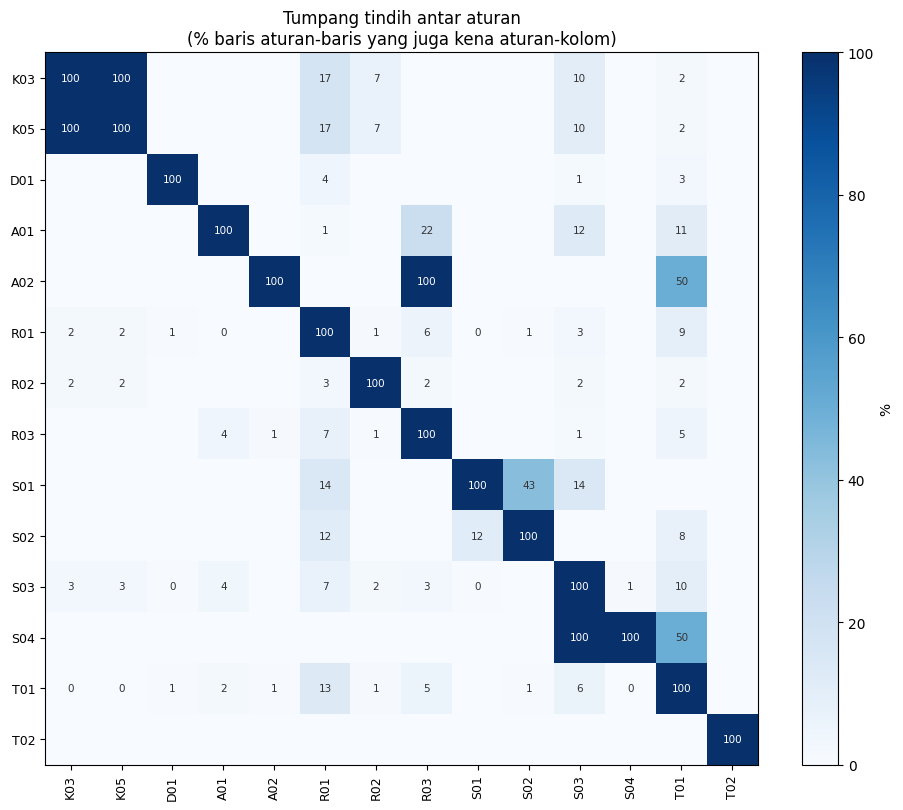

In [14]:
aktif = katalog.index[katalog['baris_kena'] > 0]
F = FLAG[aktif].astype(int)
irisan = F.T @ F
tumpang = irisan / np.diag(irisan)[:, None] * 100

fig, ax = plt.subplots(figsize=(1.2 + 0.60 * len(aktif), 1.0 + 0.50 * len(aktif)))
im = ax.imshow(tumpang.values, cmap='Blues', vmin=0, vmax=100)
ax.set_xticks(range(len(aktif)), aktif, rotation=90, fontsize=9)
ax.set_yticks(range(len(aktif)), aktif, fontsize=9)
for i in range(len(aktif)):
    for j in range(len(aktif)):
        v = tumpang.values[i, j]
        if v > 0:
            ax.text(j, i, f'{v:.0f}', ha='center', va='center', fontsize=7.5,
                    color='white' if v > 60 else '#333333')
ax.set_title('Tumpang tindih antar aturan\n(% baris aturan-baris yang juga kena aturan-kolom)')
ax.grid(False)
fig.colorbar(im, ax=ax, label='%')
plt.tight_layout()
plt.show()

## 5. Visualisasi anomali & noise

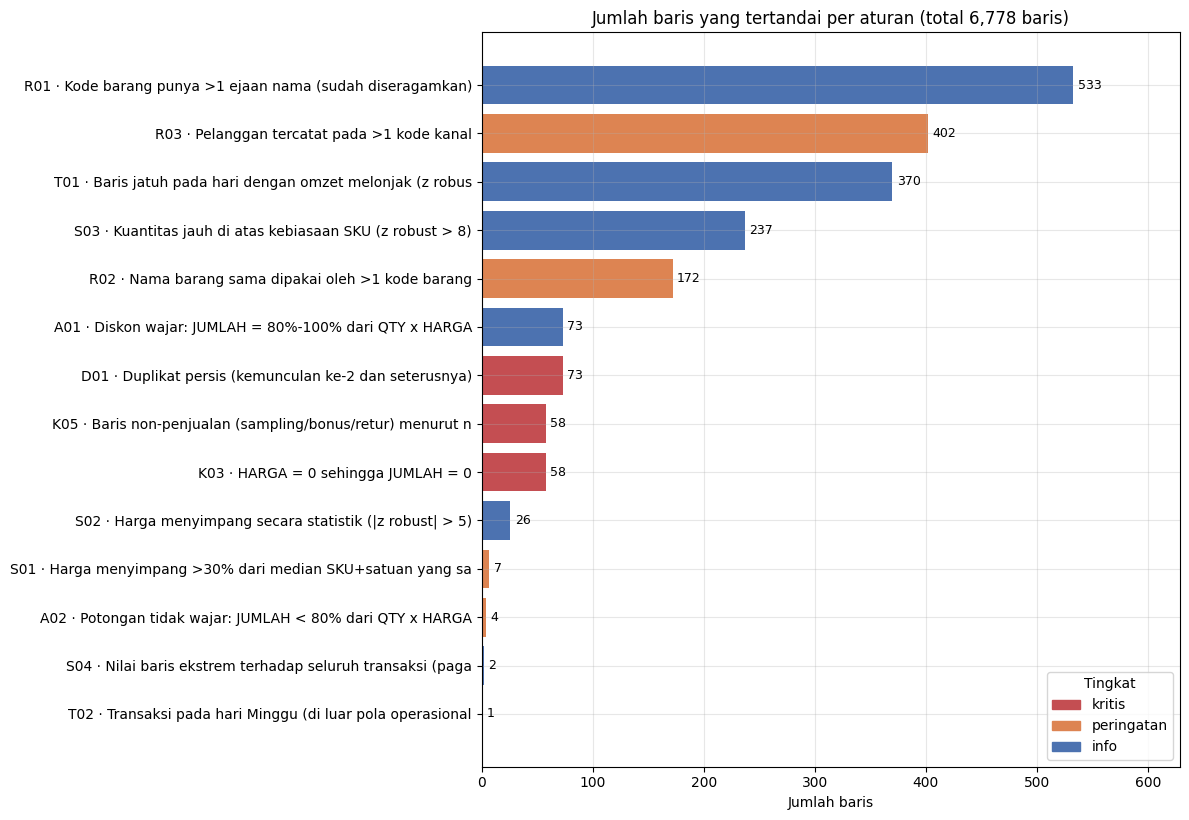

In [15]:
# 5.1 Berapa banyak baris yang kena tiap aturan, diurutkan dan diwarnai per tingkat.
tampil = katalog.loc[aktif].sort_values('baris_kena')
label = [f'{k} · {tampil.loc[k, "deskripsi"][:52]}' for k in tampil.index]

fig, ax = plt.subplots(figsize=(12, 0.45 * len(tampil) + 2))
bar = ax.barh(label, tampil['baris_kena'], color=[WARNA[t] for t in tampil['tingkat']])
ax.bar_label(bar, fmt='%d', padding=3, fontsize=9)
ax.set_title(f'Jumlah baris yang tertandai per aturan (total {len(d):,} baris)')
ax.set_xlabel('Jumlah baris')
ax.set_xlim(0, tampil['baris_kena'].max() * 1.18)
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=WARNA[t]) for t in WARNA],
          labels=list(WARNA), title='Tingkat', loc='lower right')
plt.tight_layout()
plt.show()

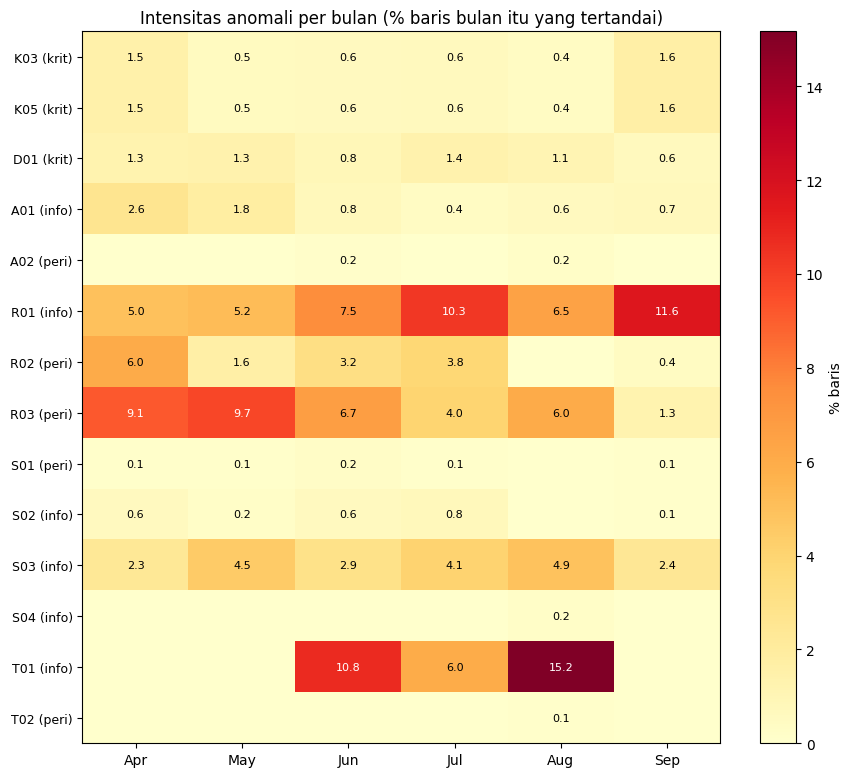

In [16]:
# 5.2 Apakah masalah kualitas data terkonsentrasi di bulan tertentu?
per_bulan = FLAG[aktif].groupby(d['BULAN']).sum().T
baris_bulan = d.groupby('BULAN').size()
laju = per_bulan / baris_bulan.values * 100
laju.columns = per_bulan.columns.strftime('%b')

fig, ax = plt.subplots(figsize=(9, 0.42 * len(aktif) + 2))
im = ax.imshow(laju.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(laju.columns)), laju.columns)
ax.set_yticks(range(len(laju.index)),
              [f'{k} ({katalog.loc[k, "tingkat"][:4]})' for k in laju.index], fontsize=9)
for i in range(laju.shape[0]):
    for j in range(laju.shape[1]):
        v = laju.values[i, j]
        if v > 0:
            ax.text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=8,
                    color='white' if v > laju.values.max() * 0.6 else 'black')
ax.set_title('Intensitas anomali per bulan (% baris bulan itu yang tertandai)')
ax.grid(False)
fig.colorbar(im, ax=ax, label='% baris')
plt.tight_layout()
plt.show()

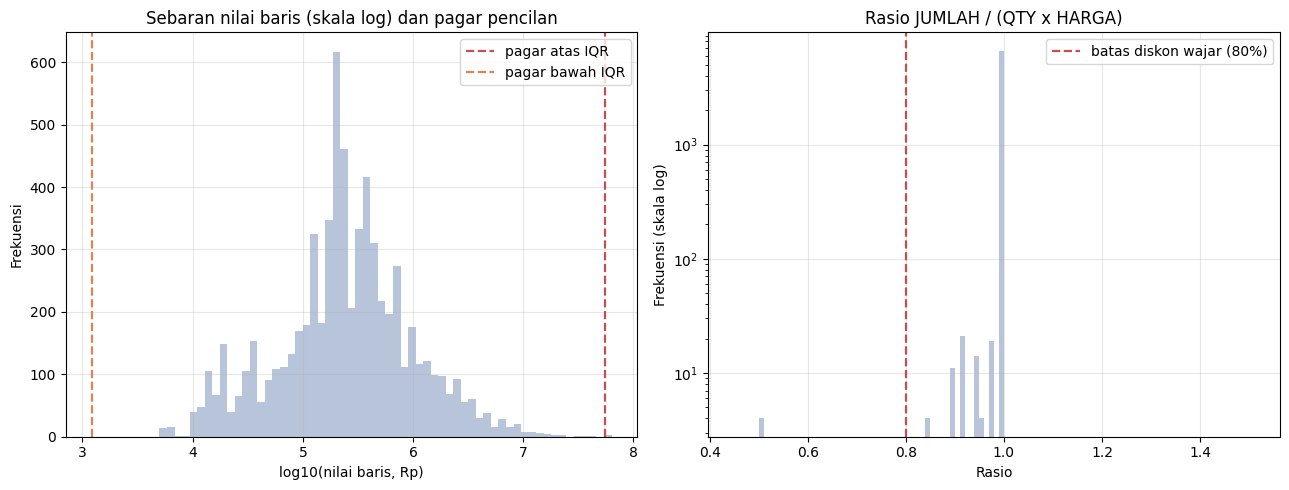

In [17]:
# 5.3 Di mana pencilan berada dalam sebaran nilai transaksi, dan seperti apa pola diskon.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(log_jumlah.dropna(), bins=60, color='#B8C4D9')
axes[0].axvline(atas, color=WARNA['kritis'], ls='--', lw=1.6, label='pagar atas IQR')
axes[0].axvline(bawah, color=WARNA['peringatan'], ls='--', lw=1.6, label='pagar bawah IQR')
axes[0].set_title('Sebaran nilai baris (skala log) dan pagar pencilan')
axes[0].set_xlabel('log10(nilai baris, Rp)')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# Puncak di 1.0 adalah baris normal; puncak-puncak kecil di kirinya adalah tingkat
# diskon yang dipakai berulang — inilah bukti bahwa selisih itu terstruktur.
r = d.loc[d['RASIO'].notna() & d['RASIO'].between(0.45, 1.5), 'RASIO']
axes[1].hist(r, bins=np.arange(0.45, 1.52, 0.01), color='#B8C4D9')
axes[1].axvline(BATAS_DISKON, color=WARNA['kritis'], ls='--', lw=1.6,
                label=f'batas diskon wajar ({BATAS_DISKON:.0%})')
axes[1].set_yscale('log')
axes[1].set_title('Rasio JUMLAH / (QTY x HARGA)')
axes[1].set_xlabel('Rasio')
axes[1].set_ylabel('Frekuensi (skala log)')
axes[1].legend()
plt.tight_layout()
plt.show()

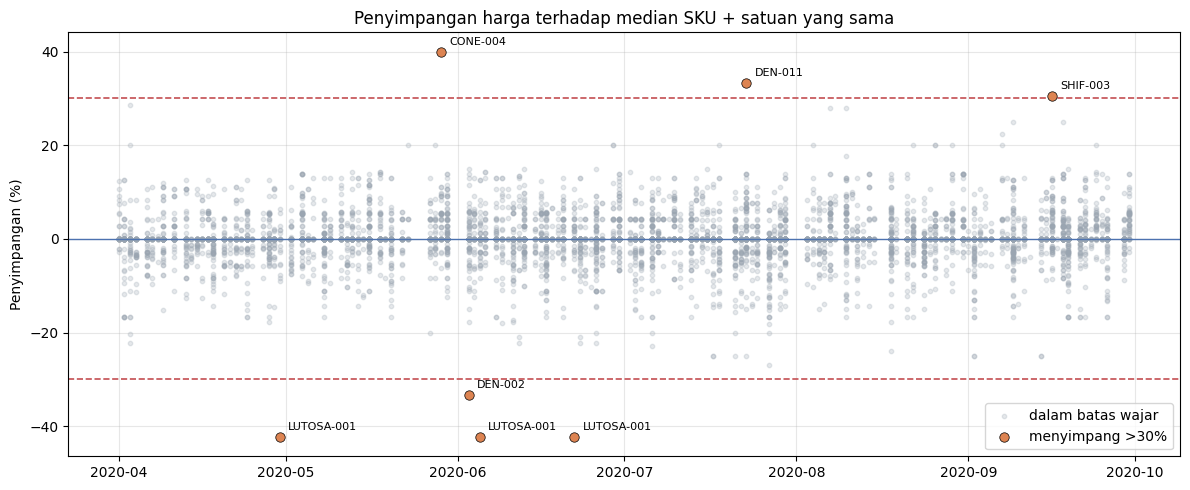

In [18]:
# 5.4 Penyimpangan harga terhadap median SKU+satuan, sepanjang waktu.
punya_dev = d['DEV_HARGA'].notna() & np.isfinite(d['DEV_HARGA'])
menyimpang = punya_dev & (d['DEV_HARGA'].abs() > 0.30)
wajar = punya_dev & ~menyimpang
dev_persen = d['DEV_HARGA'] * 100

fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(d.loc[wajar, 'TGL'], dev_persen[wajar],
           s=10, alpha=0.25, color='#9AA5B1', label='dalam batas wajar')
ax.scatter(d.loc[menyimpang, 'TGL'], dev_persen[menyimpang],
           s=46, color=WARNA['peringatan'], edgecolor='black', lw=0.5, zorder=3,
           label='menyimpang >30%')
ax.axhline(0, color='#4C72B0', lw=1)
for batas in (30, -30):
    ax.axhline(batas, color=WARNA['kritis'], ls='--', lw=1.2)
for idx in d.index[menyimpang]:
    ax.annotate(d.loc[idx, 'KODE'], (d.loc[idx, 'TGL'], dev_persen[idx]),
                textcoords='offset points', xytext=(6, 5), fontsize=8)
ax.set_title('Penyimpangan harga terhadap median SKU + satuan yang sama')
ax.set_ylabel('Penyimpangan (%)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

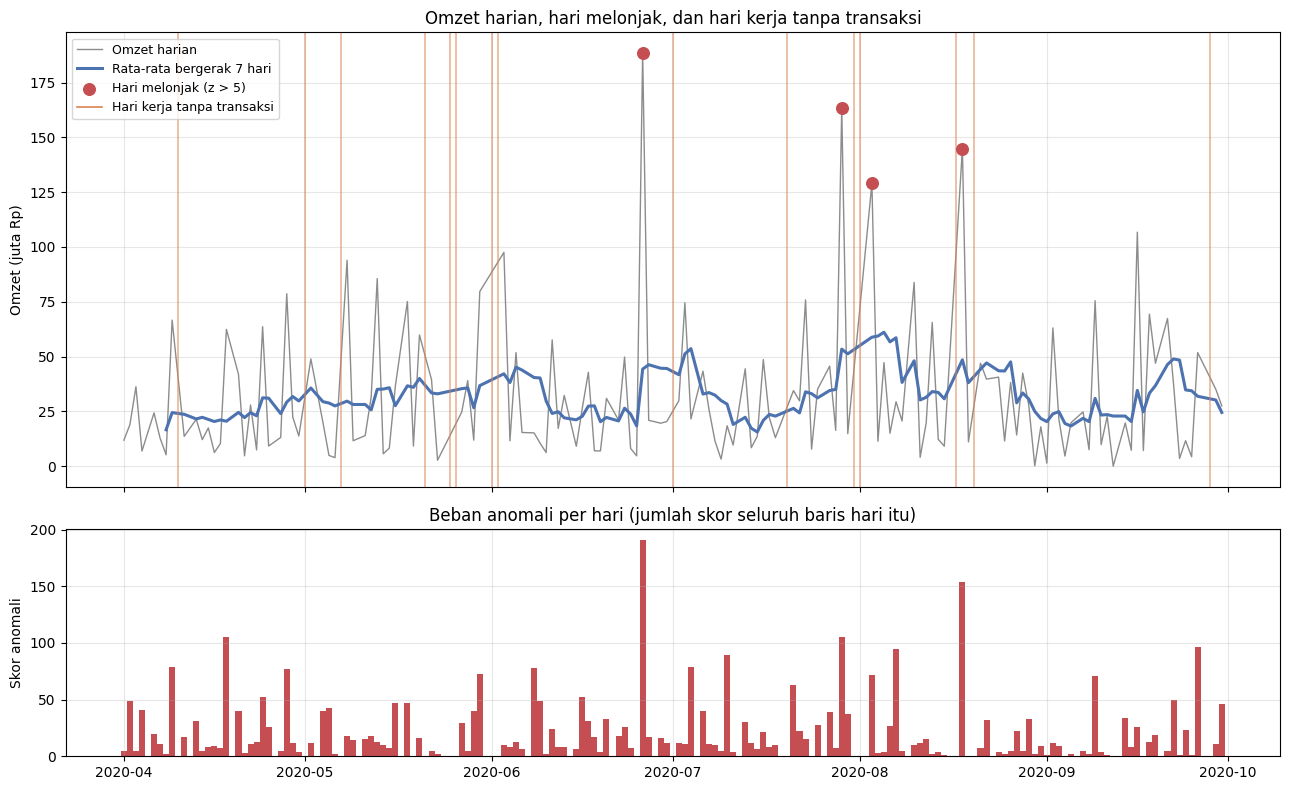

In [19]:
# 5.5 Garis waktu: di mana anomali menempel pada omzet harian, dan di mana hari kosong.
skor_hari = d.groupby('TGL')['SKOR_ANOMALI'].sum()

fig, (ax, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True,
                              gridspec_kw={'height_ratios': [2, 1]})

ax.plot(harian.index, harian.values / 1e6, lw=1.0, color='#8C8C8C', label='Omzet harian')
ax.plot(harian.index, harian.rolling(7).mean() / 1e6, lw=2.2, color='#4C72B0',
        label='Rata-rata bergerak 7 hari')
if tgl_lonjakan:
    lonjak = sorted(tgl_lonjakan)
    ax.scatter(lonjak, harian[lonjak] / 1e6, s=70, color=WARNA['kritis'], zorder=3,
               label='Hari melonjak (z > 5)')
for t in kosong_kerja:
    ax.axvline(t, color=WARNA['peringatan'], lw=1.2, alpha=0.6)
ax.plot([], [], color=WARNA['peringatan'], lw=1.2, label='Hari kerja tanpa transaksi')
ax.set_ylabel('Omzet (juta Rp)')
ax.set_title('Omzet harian, hari melonjak, dan hari kerja tanpa transaksi')
ax.legend(loc='upper left', fontsize=9)

ax2.bar(skor_hari.index, skor_hari.values, color='#C44E52', width=1.0)
ax2.set_ylabel('Skor anomali')
ax2.set_title('Beban anomali per hari (jumlah skor seluruh baris hari itu)')
plt.tight_layout()
plt.show()

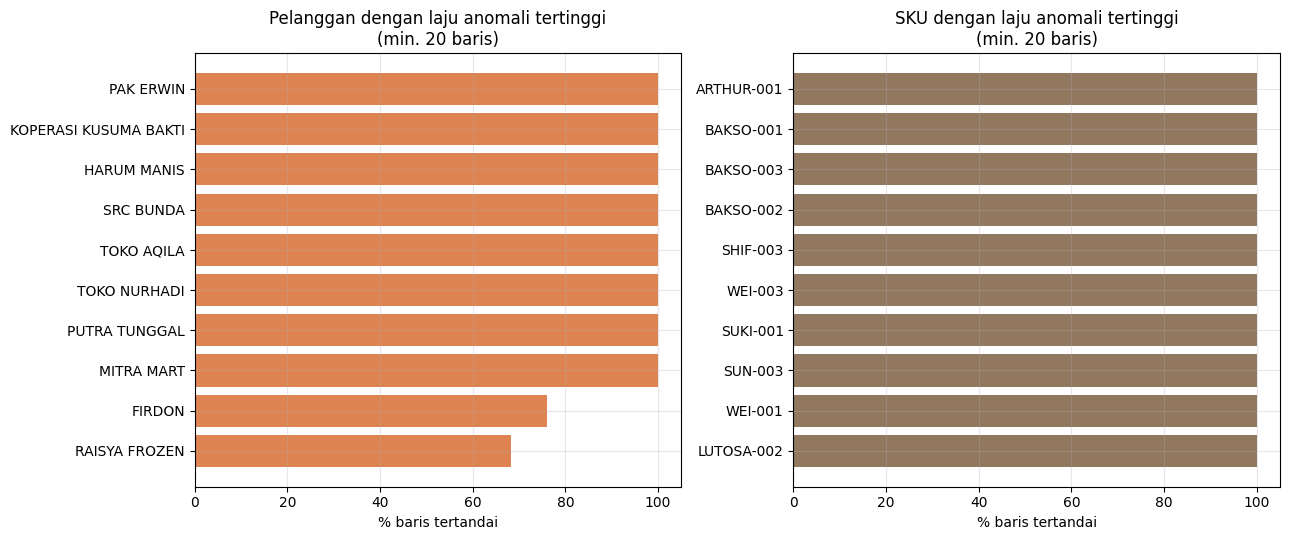

,baris,tertandai,laju_%
PELANGGAN,,,
PAK ERWIN,129,129,100.00
KOPERASI KUSUMA BAKTI,31,31,100.00
HARUM MANIS,49,49,100.00
SRC BUNDA,21,21,100.00
TOKO AQILA,26,26,100.00
TOKO NURHADI,43,43,100.00
PUTRA TUNGGAL,33,33,100.00
MITRA MART,22,22,100.00
FIRDON,25,19,76.00


In [20]:
# 5.6 Apakah anomali menumpuk di pelanggan atau SKU tertentu? Kalau ya, akarnya biasanya
# satu proses input yang keliru, bukan kesalahan acak — dan itu bisa diperbaiki di hulu.
def laju_anomali(kolom, min_baris=20, n=10):
    g = d.groupby(kolom).agg(baris=('JUMLAH', 'size'),
                             tertandai=('N_FLAG', lambda s: int((s > 0).sum())))
    g = g[g['baris'] >= min_baris]
    g['laju_%'] = (g['tertandai'] / g['baris'] * 100).round(1)
    return g.sort_values('laju_%', ascending=False).head(n)


top_pel = laju_anomali('PELANGGAN')
top_sku = laju_anomali('KODE')

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
axes[0].barh([s[:34] for s in top_pel.index][::-1], top_pel['laju_%'][::-1], color='#DD8452')
axes[0].set_title('Pelanggan dengan laju anomali tertinggi\n(min. 20 baris)')
axes[0].set_xlabel('% baris tertandai')
axes[1].barh([s[:34] for s in top_sku.index][::-1], top_sku['laju_%'][::-1], color='#937860')
axes[1].set_title('SKU dengan laju anomali tertinggi\n(min. 20 baris)')
axes[1].set_xlabel('% baris tertandai')
plt.tight_layout()
plt.show()

display(top_pel)

## 6. Kebijakan pembersihan

Sampai titik ini tidak ada satu pun baris yang dibuang selain baris kosong. Keputusan
dibuat di sini, dalam satu tabel kebijakan, dengan tiga tindakan yang mungkin:

- **`keluarkan`** — baris tidak boleh ikut agregat omzet (ganda, tidak valid, non-penjualan).
- **`perbaiki`** — nilainya dikoreksi, barisnya tetap dipakai.
- **`tandai`** — barisnya dipakai apa adanya, cukup dicatat untuk verifikasi.

Yang penting: **pencilan tidak dibuang.** Pesanan 400 DUS dan transaksi puluhan juta
rupiah adalah penjualan sungguhan; membuangnya berarti mengecilkan omzet yang benar-benar
terjadi. Yang dibuang hanyalah baris yang secara definisi bukan penjualan, atau yang
tercatat dua kali.

In [21]:
# Kebijakan per aturan. Ubah nilai di sini untuk mengubah hasil pembersihan — tidak ada
# logika penghapusan yang tersembunyi di sel lain.
KEBIJAKAN = {
    'K01': 'keluarkan',   # kolom kunci kosong -> tak bisa dianalisis
    'K02': 'keluarkan',   # QTY <= 0
    'K03': 'keluarkan',   # sampling/bonus, nilai nol
    'K04': 'tandai',      # kombinasi janggal, perlu konfirmasi dulu
    'K05': 'keluarkan',   # non-penjualan
    'D01': 'keluarkan',   # duplikat persis
    'D02': 'tandai',      # duplikat lunak: bisa sah
    'A01': 'perbaiki',    # diskon wajar -> pakai JUMLAH sebagai omzet
    'A02': 'tandai',
    'A03': 'tandai',
    'R01': 'perbaiki',    # ejaan nama sudah diseragamkan di Bagian 2
    'R02': 'tandai',
    'R03': 'perbaiki',    # kanal diseragamkan lewat KANAL_K
    'S01': 'tandai',
    'S02': 'tandai',
    'S03': 'tandai',
    'S04': 'tandai',
    'T01': 'tandai',
    'T02': 'tandai',
}
katalog['tindakan'] = pd.Series(KEBIJAKAN)
assert katalog['tindakan'].notna().all(), 'Ada aturan yang belum punya kebijakan.'

kode_keluar = katalog.index[katalog['tindakan'] == 'keluarkan']
d['DIKELUARKAN'] = FLAG[kode_keluar].any(axis=1)
d['ALASAN_KELUAR'] = [','.join(kode_keluar[r])
                      for r in FLAG[kode_keluar].to_numpy()]
d['LAYAK_ANALISIS'] = ~d['DIKELUARKAN']

display(katalog[['kategori', 'tingkat', 'baris_kena', 'tindakan', 'saran']]
        .sort_values(['tindakan', 'tingkat']))

alasan = d.loc[d['DIKELUARKAN'], 'ALASAN_KELUAR'].value_counts().rename('baris').to_frame()
alasan['persen'] = (alasan['baris'] / len(d) * 100).round(2)
print(f'\nBaris dikeluarkan: {int(d["DIKELUARKAN"].sum())} '
      f'({d["DIKELUARKAN"].mean() * 100:.2f}% dari {len(d):,})')
display(alasan)

,kategori,tingkat,baris_kena,tindakan,saran
kode,,,,,
K01,kelengkapan,kritis,0,keluarkan,Baris tidak dapat dianalisis — keluarkan dari ...
K02,validitas,kritis,0,keluarkan,Cek apakah retur (harus bernilai negatif konsi...
K03,validitas,kritis,58,keluarkan,Barang keluar tanpa nilai jual: sampling/bonus...
K05,noise,kritis,58,keluarkan,Bukan omzet. Pisahkan agar tidak mengencerkan ...
D01,duplikasi,kritis,73,keluarkan,Hapus salinan berlebih; pertahankan kemunculan...
A01,aritmetika,info,73,perbaiki,Sah. Pakai JUMLAH (bukan QTY x HARGA) sebagai ...
R01,referensial,info,533,perbaiki,Perbaiki master barang di sistem sumber agar e...
R03,referensial,peringatan,402,perbaiki,Tentukan kanal yang benar; analisis per kanal ...
S02,pencilan,info,26,tandai,"Menyimpang dari kebiasaan SKU ini, tetapi bisa..."



Baris dikeluarkan: 131 (1.93% dari 6,778)


,baris,persen
ALASAN_KELUAR,,
D01,73,1.08
"K03,K05",58,0.86


In [22]:
# Dataset final. OMZET dihitung dari JUMLAH, bukan QTY x HARGA, karena JUMLAH sudah
# memuat diskon yang terdeteksi di aturan A01.
KOLOM_FINAL = ['BARIS_ASLI', 'TGL', 'BULAN', 'HARI', 'KODE', 'NAMA_BARANG', 'BRAND',
               'QTY', 'SATUAN_K', 'HARGA', 'HARGA_EFEKTIF', 'JUMLAH', 'RASIO',
               'PELANGGAN', 'KANAL_K', 'GRUP', 'TINGKAT_TERTINGGI', 'SKOR_ANOMALI', 'FLAG']

bersih = (d.loc[d['LAYAK_ANALISIS'], KOLOM_FINAL]
          .rename(columns={'SATUAN_K': 'SATUAN', 'KANAL_K': 'KANAL', 'JUMLAH': 'OMZET'})
          .reset_index(drop=True))

print(f'Baris mentah          : {len(mentah):,}')
print(f'Setelah normalisasi   : {len(d):,}')
print(f'Layak analisis        : {len(bersih):,} ({len(bersih) / len(mentah) * 100:.1f}%)')
print(f'Masih membawa catatan : {int((bersih["SKOR_ANOMALI"] > 0).sum()):,} baris '
      f'({(bersih["SKOR_ANOMALI"] > 0).mean() * 100:.1f}%) — dipakai, tetapi tercatat')
bersih.head()

Baris mentah          : 6,779
Setelah normalisasi   : 6,778
Layak analisis        : 6,647 (98.1%)
Masih membawa catatan : 1,605 baris (24.1%) — dipakai, tetapi tercatat


,BARIS_ASLI,TGL,BULAN,HARI,KODE,NAMA_BARANG,BRAND,QTY,SATUAN,HARGA,HARGA_EFEKTIF,OMZET,RASIO,PELANGGAN,KANAL,GRUP,TINGKAT_TERTINGGI,SKOR_ANOMALI,FLAG
0,2,2020-04-01,2020-04-01,Wednesday,JOF-022,JOFRANS NUGGET AYAM REG. 225 GR X 24 PAK,JOFRANS,1.00,DUS,"240,000.00","240,000.00","240,000.00",1.00,TOKO SALMAINI HABABAHAN,F,MITRAKU,bersih,0,
1,3,2020-04-01,2020-04-01,Wednesday,JOF-002,JOFRANS NUGGET AYAM REG. 500 GR X 12 PAK,JOFRANS,1.00,DUS,"216,000.00","216,000.00","216,000.00",1.00,TOKO SALMAINI HABABAHAN,F,MITRAKU,bersih,0,
2,4,2020-04-01,2020-04-01,Wednesday,OKEY-003,OKEY STICK 500 GR X 10 PACK,OKEY,1.00,DUS,"190,000.00","190,000.00","190,000.00",1.00,TOKO SALMAINI HABABAHAN,F,MITRAKU,bersih,0,
3,5,2020-04-01,2020-04-01,Wednesday,OKEY-001,OKEY SOSIS 500 GR X 20 PACK,OKEY,1.00,DUS,"380,000.00","380,000.00","380,000.00",1.00,TOKO SALMAINI HABABAHAN,F,MITRAKU,bersih,0,
4,6,2020-04-01,2020-04-01,Wednesday,BLF-001,BELFOODS SOSIS AYAM 500 GR X 12 PACK,BELFOODS,1.00,DUS,"204,000.00","204,000.00","204,000.00",1.00,TOKO SALMAINI HABABAHAN,F,MITRAKU,bersih,0,


## 7. Dampak pembersihan: sebelum vs sesudah

In [23]:
def kpi(frame, kol_nilai, kol_pelanggan, kol_sku):
    return pd.Series({
        'Baris': len(frame),
        'Total omzet (Rp)': frame[kol_nilai].sum(),
        'Rata-rata nilai baris (Rp)': frame[kol_nilai].mean(),
        'Median nilai baris (Rp)': frame[kol_nilai].median(),
        'Pelanggan unik': frame[kol_pelanggan].nunique(),
        'SKU unik': frame[kol_sku].nunique(),
        'Total kuantitas': frame['QTY'].sum(),
    })


# "Sebelum" sengaja memakai kolom mentah (NAMA, KODEBARA) tanpa penyatuan identitas —
# itulah kondisi yang akan dihadapi analisis kalau notebook ini tidak dijalankan.
banding = pd.DataFrame({
    'sebelum': kpi(d, 'JUMLAH', 'NAMA', 'KODEBARA'),
    'sesudah': kpi(bersih, 'OMZET', 'PELANGGAN', 'KODE'),
})
banding['selisih'] = banding['sesudah'] - banding['sebelum']
banding['selisih_%'] = (banding['selisih'] / banding['sebelum'] * 100).round(2)
display(banding)

,sebelum,sesudah,selisih,selisih_%
Baris,"6,778.00","6,647.00",-131.00,-1.93
Total omzet (Rp),"4,530,330,620.00","4,516,416,920.00","-13,913,700.00",-0.31
Rata-rata nilai baris (Rp),"668,387.52","679,466.97","11,079.44",1.66
Median nilai baris (Rp),"240,000.00","240,000.00",0.00,0.00
Pelanggan unik,229.00,181.00,-48.00,-20.96
SKU unik,268.00,268.00,0.00,0.00
Total kuantitas,"46,704.00","45,929.00",-775.00,-1.66


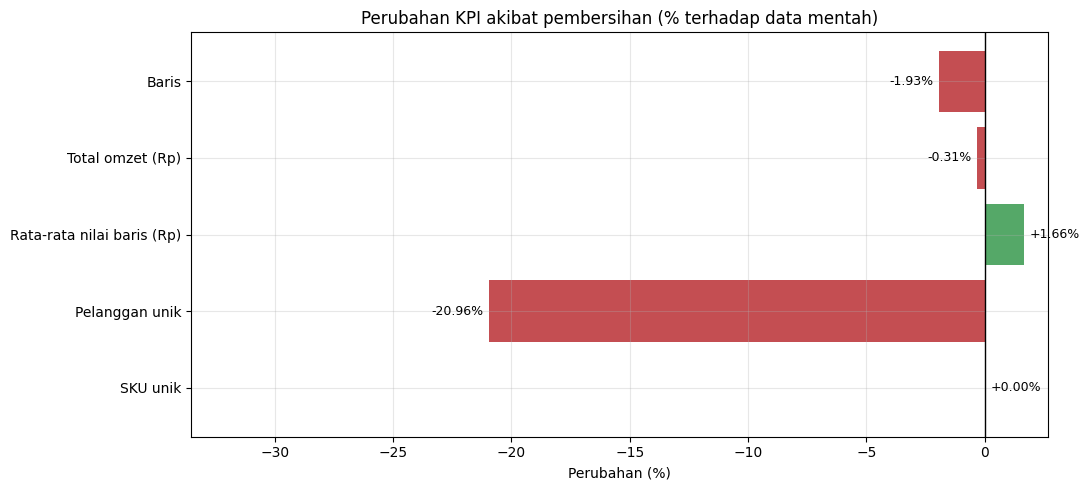

Pembacaan: turunnya jumlah pelanggan unik BUKAN kehilangan pelanggan, melainkan
penggabungan satu outlet yang sebelumnya tercatat dengan dua ejaan berbeda.


In [24]:
metrik = ['Baris', 'Total omzet (Rp)', 'Rata-rata nilai baris (Rp)',
          'Pelanggan unik', 'SKU unik']
perubahan = banding.loc[metrik, 'selisih_%']

fig, ax = plt.subplots(figsize=(11, 5))
warna = [WARNA['kritis'] if v < 0 else '#55A868' for v in perubahan]
bar = ax.barh([m[:34] for m in metrik][::-1], perubahan.values[::-1], color=warna[::-1])
ax.bar_label(bar, fmt='%+.2f%%', padding=4, fontsize=9)
ax.axvline(0, color='black', lw=1)
ax.set_title('Perubahan KPI akibat pembersihan (% terhadap data mentah)')
ax.set_xlabel('Perubahan (%)')
ax.set_xlim(min(perubahan.min() * 1.6, -2), max(perubahan.max() * 1.6, 2))
plt.tight_layout()
plt.show()

print('Pembacaan: turunnya jumlah pelanggan unik BUKAN kehilangan pelanggan, melainkan')
print('penggabungan satu outlet yang sebelumnya tercatat dengan dua ejaan berbeda.')

In [25]:
# Apakah pembersihan mengubah kesimpulan, bukan sekadar angkanya?
pel_sebelum = d.groupby('NAMA')['JUMLAH'].sum().sort_values(ascending=False).head(10)
pel_sesudah = bersih.groupby('PELANGGAN')['OMZET'].sum().sort_values(ascending=False).head(10)

display(pd.DataFrame({
    'peringkat': range(1, 11),
    'sebelum (NAMA mentah)': pel_sebelum.index,
    'omzet_sebelum (juta)': (pel_sebelum.values / 1e6).round(1),
    'sesudah (PELANGGAN bersih)': pel_sesudah.index,
    'omzet_sesudah (juta)': (pel_sesudah.values / 1e6).round(1),
}).set_index('peringkat'))

lama = {str(x).upper().split(' - ')[-1].strip() for x in pel_sebelum.index}
pindah = [p for p in pel_sesudah.index if p not in lama]
print(f'Pelanggan yang baru masuk 10 besar setelah identitas disatukan: {pindah}')

,sebelum (NAMA mentah),omzet_sebelum (juta),sesudah (PELANGGAN bersih),omzet_sesudah (juta)
peringkat,,,,
1,TOKO CITA RASA BARU,433.50,TOKO CITA RASA BARU,547.80
2,ADEK FROZEN,288.30,ADEK FROZEN,420.10
3,ANTON,212.70,ANTON,311.80
4,HITE,162.10,HITE,229.90
5,F - (MITRAKU) PT. DINAMIKA BUAH N.,139.90,RUMAH SOSIS,182.70
6,C - ADEK FROZEN,132.50,GRAHA SANDENI,163.20
7,RUMAH SOSIS,130.10,FIRDON,154.80
8,GRAHA SANDENI,127.60,PT. DINAMIKA BUAH N.,136.80
9,PAK SUTARMUJI,126.40,PAK SUTARMUJI,126.40


Pelanggan yang baru masuk 10 besar setelah identitas disatukan: ['FIRDON', 'PT. DINAMIKA BUAH N.', 'KUBANG JAYA FOOD']


## 8. Ekspor & ringkasan temuan

In [26]:
os.makedirs(DIR_KELUARAN, exist_ok=True)

# 1) Dataset siap analisis.
p_bersih = os.path.join(DIR_KELUARAN, 'penjualan_bersih.csv')
bersih.to_csv(p_bersih, index=False)

# 2) Log anomali: satu baris per (baris data x aturan) agar mudah difilter dan
#    dibagikan ke tim yang memverifikasi ke dokumen sumber.
log = (FLAG.stack().rename('kena').reset_index()
       .rename(columns={'level_0': 'idx', 'level_1': 'kode_aturan'}))
log = log[log['kena']].drop(columns='kena')
log = log.join(d[['BARIS_ASLI', 'TGL', 'KODE', 'NAMA_BARANG', 'QTY', 'SATUAN_K',
                  'HARGA', 'JUMLAH', 'PELANGGAN', 'SKOR_ANOMALI']], on='idx')
log = log.join(katalog[['kategori', 'tingkat', 'deskripsi', 'tindakan', 'saran']],
               on='kode_aturan')
log = log.drop(columns='idx').sort_values(['tingkat', 'kode_aturan', 'BARIS_ASLI'])
p_log = os.path.join(DIR_KELUARAN, 'log_anomali.csv')
log.to_csv(p_log, index=False)

# 3) Katalog aturan beserta hasilnya, sebagai dokumentasi keputusan.
p_katalog = os.path.join(DIR_KELUARAN, 'katalog_aturan.csv')
katalog.to_csv(p_katalog)

for p in (p_bersih, p_log, p_katalog):
    print(f'{p:<40} {os.path.getsize(p) / 1024:>8,.1f} KB')
print(f'\nlog_anomali.csv berisi {len(log):,} temuan pada '
      f'{log["BARIS_ASLI"].nunique():,} baris berbeda.')
display(log.head(10))

bersih\penjualan_bersih.csv               1,058.8 KB
bersih\log_anomali.csv                      495.7 KB
bersih\katalog_aturan.csv                     3.0 KB

log_anomali.csv berisi 2,016 temuan pada 1,736 baris berbeda.


,kode_aturan,BARIS_ASLI,TGL,KODE,NAMA_BARANG,QTY,SATUAN_K,HARGA,JUMLAH,PELANGGAN,SKOR_ANOMALI,kategori,tingkat,deskripsi,tindakan,saran
748,A01,41,2020-04-02,MIT-010,MITRAKU FISH ROLL 250 GR X 25 PACK,13.00,PACK,"13,000.00","155,480.00",RAISYA FROZEN,1,aritmetika,info,Diskon wajar: JUMLAH = 80%-100% dari QTY x HARGA,perbaiki,Sah. Pakai JUMLAH (bukan QTY x HARGA) sebagai ...
767,A01,42,2020-04-02,MIT-009,MITRAKU FISH ROLL 500 GR X 20 PACK,6.00,PACK,"23,400.00","129,168.00",RAISYA FROZEN,1,aritmetika,info,Diskon wajar: JUMLAH = 80%-100% dari QTY x HARGA,perbaiki,Sah. Pakai JUMLAH (bukan QTY x HARGA) sebagai ...
786,A01,43,2020-04-02,MIT-011,MITRAKU FISH ROLL 1000 GR X 10 PACK,4.00,PACK,"46,000.00","169,280.00",RAISYA FROZEN,1,aritmetika,info,Diskon wajar: JUMLAH = 80%-100% dari QTY x HARGA,perbaiki,Sah. Pakai JUMLAH (bukan QTY x HARGA) sebagai ...
919,A01,50,2020-04-02,MIT-016,MITRAKU FISH CAKE SINGAPORE 1000 GR X 10,6.00,PACK,"52,000.00","287,040.00",RAISYA FROZEN,1,aritmetika,info,Diskon wajar: JUMLAH = 80%-100% dari QTY x HARGA,perbaiki,Sah. Pakai JUMLAH (bukan QTY x HARGA) sebagai ...
1052,A01,57,2020-04-02,MIT-004,MITRAKU BAKSO PILUS IKAN 400GR X 23 PACK,10.00,PACK,"14,900.00","141,550.00",MAJU JAYA,1,aritmetika,info,Diskon wajar: JUMLAH = 80%-100% dari QTY x HARGA,perbaiki,Sah. Pakai JUMLAH (bukan QTY x HARGA) sebagai ...
1071,A01,58,2020-04-02,MIT-009,MITRAKU FISH ROLL 500 GR X 20 PACK,10.00,PACK,"23,400.00","222,300.00",MAJU JAYA,1,aritmetika,info,Diskon wajar: JUMLAH = 80%-100% dari QTY x HARGA,perbaiki,Sah. Pakai JUMLAH (bukan QTY x HARGA) sebagai ...
1090,A01,59,2020-04-02,MIT-010,MITRAKU FISH ROLL 250 GR X 25 PACK,5.00,PACK,"13,000.00","61,750.00",MAJU JAYA,1,aritmetika,info,Diskon wajar: JUMLAH = 80%-100% dari QTY x HARGA,perbaiki,Sah. Pakai JUMLAH (bukan QTY x HARGA) sebagai ...
7474,A01,395,2020-04-11,MIT-016,MITRAKU FISH CAKE SINGAPORE 1000 GR X 10,5.00,DUS,"520,000.00","2,340,000.00",PAK SUPRI,1,aritmetika,info,Diskon wajar: JUMLAH = 80%-100% dari QTY x HARGA,perbaiki,Sah. Pakai JUMLAH (bukan QTY x HARGA) sebagai ...
8082,A01,427,2020-04-13,MANTUL-001,MANTUL BAKSO IKAN 500 GR X 20 PACK,1.00,DUS,"334,000.00","317,300.00",RAISYA FROZEN,1,aritmetika,info,Diskon wajar: JUMLAH = 80%-100% dari QTY x HARGA,perbaiki,Sah. Pakai JUMLAH (bukan QTY x HARGA) sebagai ...
8101,A01,428,2020-04-13,MANTUL-002,MANTUL BAKSO IKAN RASA UDANG 500 GR X 20,1.00,DUS,"334,000.00","317,300.00",RAISYA FROZEN,1,aritmetika,info,Diskon wajar: JUMLAH = 80%-100% dari QTY x HARGA,perbaiki,Sah. Pakai JUMLAH (bukan QTY x HARGA) sebagai ...


In [27]:
# Ringkasan ditulis dari variabel, bukan diketik manual, agar ikut berubah ketika ambang
# atau kebijakan di atas disetel ulang.
omzet_sebelum, omzet_sesudah = d['JUMLAH'].sum(), bersih['OMZET'].sum()
n_diskon = int(FLAG['A01'].sum())
n_potongan_janggal = int(FLAG['A02'].sum() + FLAG['A03'].sum())

garis = '─' * 78
print(garis)
print('RINGKASAN PEMBERSIHAN DATA & PENANDAAN ANOMALI'.center(78))
print(garis)
print(f'Periode     : {d["TGL"].min():%d %b %Y} – {d["TGL"].max():%d %b %Y} '
      f'({len(harian)} hari aktif dari {len(kalender)} hari kalender)')
print(f'Baris       : {len(mentah):,} mentah → {len(d):,} setelah normalisasi '
      f'→ {len(bersih):,} layak analisis')
print(f'Omzet       : Rp {omzet_sebelum:,.0f} → Rp {omzet_sesudah:,.0f} '
      f'({(omzet_sesudah / omzet_sebelum - 1) * 100:+.2f}%)')
print()
print('TEMUAN UTAMA')
print(f'  1. Identitas pelanggan ganda — {n_varian} outlet tertulis dalam lebih dari satu')
print(f'     bentuk (mis. "ADEK FROZEN" vs "C - ADEK FROZEN"). Tanpa penyatuan, jumlah')
print(f'     pelanggan melar dari {d["PELANGGAN"].nunique()} menjadi {d["NAMA"].nunique()}.')
print(f'  2. Duplikasi — {int(FLAG["D01"].sum())} salinan persis dikeluarkan; '
      f'{int(FLAG["D02"].sum())} duplikat lunak (mirip,')
print(f'     tidak persis) ditandai saja, karena dua struk sah di hari yang sama juga')
print(f'     berbentuk seperti itu.')
print(f'  3. JUMLAH ≠ QTY × HARGA pada {int(tak_cocok.sum())} baris, dan {n_diskon} di antaranya')
print(f'     berpola diskon rapi — bukan salah hitung. JUMLAH dipakai sebagai omzet.')
print(f'     Sisanya {n_potongan_janggal} baris berpotongan tidak wajar dan perlu konfirmasi.')
print(f'  4. Non-penjualan — {int(FLAG["K05"].sum())} baris bernilai nol (sampling/bonus),')
print(f'     dipisahkan agar tidak mengencerkan rata-rata nilai transaksi.')
print(f'  5. Harga menyimpang >30% dari median SKU+satuan pada {int(FLAG["S01"].sum())} baris —')
print(f'     daftar pendek yang layak dicek ke nota asli.')
print(f'  6. Hari kosong bersifat struktural: {minggu_kosong} dari {minggu_total} hari Minggu tanpa')
print(f'     transaksi, hanya {len(kosong_kerja)} hari kerja yang kosong. Bukan data hilang.')
print()
print('KLASIFIKASI AKHIR')
for t in ['kritis', 'peringatan', 'info', 'bersih']:
    n = int((d['TINGKAT_TERTINGGI'] == t).sum())
    print(f'  {t:<12}: {n:>6,} baris ({n / len(d) * 100:5.2f}%)')
print()
print('LANGKAH LANJUTAN')
print(f'  • Verifikasi manual {int((d["TINGKAT_TERTINGGI"] == "peringatan").sum())} baris '
      f'bertingkat "peringatan" lewat {p_log}.')
print('  • Perbaiki master barang (ejaan nama & kode ganda) dan master pelanggan')
print('    (prefiks kanal) di sistem sumber agar masalahnya tidak berulang.')
print(f'  • Gunakan {p_bersih} sebagai masukan analisis lanjutan.')
print(garis)

──────────────────────────────────────────────────────────────────────────────
                RINGKASAN PEMBERSIHAN DATA & PENANDAAN ANOMALI                
──────────────────────────────────────────────────────────────────────────────
Periode     : 01 Apr 2020 – 30 Sep 2020 (143 hari aktif dari 183 hari kalender)
Baris       : 6,779 mentah → 6,778 setelah normalisasi → 6,647 layak analisis
Omzet       : Rp 4,530,330,620 → Rp 4,516,416,920 (-0.31%)

TEMUAN UTAMA
  1. Identitas pelanggan ganda — 46 outlet tertulis dalam lebih dari satu
     bentuk (mis. "ADEK FROZEN" vs "C - ADEK FROZEN"). Tanpa penyatuan, jumlah
     pelanggan melar dari 183 menjadi 229.
  2. Duplikasi — 73 salinan persis dikeluarkan; 0 duplikat lunak (mirip,
     tidak persis) ditandai saja, karena dua struk sah di hari yang sama juga
     berbentuk seperti itu.
  3. JUMLAH ≠ QTY × HARGA pada 77 baris, dan 73 di antaranya
     berpola diskon rapi — bukan salah hitung. JUMLAH dipakai sebagai omzet.
     Sisanya 4 bari